### Business Question
Assess the geothermal potential of the area using the provided well data and determine whether the geothermal resources can support the district heating and cooling?

#### Parameters/Features
- Permeability:	Controls fluid movement
- Thickness:	Controls reservoir size
- Porosity:	Controls fluid storage
- Power (MW):	Energy generation capability
- Heat in Place:	Total geothermal energy available
- Transmissivity: Reservoir productivity


### Data Collection & Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
import pandas as pd

path = "c:/working_files/THERMO_GIS_cleaned.xlsx"

thermogis_df = pd.concat(
    pd.read_excel(path, sheet_name=None).values(),
    ignore_index=True
)

In [3]:
thermogis_df.head(5)

,Scenerio,Well_id,X,Y,Permeablity(mD),Top_Depth(m),Thickness(m),Porosity(%),Net_to_gross,Transmissivity(Dm),Temperature(celcius),Flow_rate(m^3/h),Power(MW),Heat_in_place(GJ/m^2),Potential_recov_heat(GJ/m^2),Economic_potential
0,P90,BLT_01,141577.55,456881.76,13,1837,67,17,0.98,1.3,77,17,0.6,24.8,5.8,1
1,P50,BLT_01,141577.55,456881.76,82,1837,130,17,0.98,9.3,77,105,5.1,24.8,5.8,1
2,P10,BLT_01,141577.55,456881.76,521,1837,194,17,0.98,66.1,77,469,23.7,24.8,5.8,1
3,P90,EVD_01,136997.00,441189.00,3,1723,39,9,0.99,0.2,72,0,0.0,13.1,0.0,0
4,P50,EVD_01,136997.00,441189.00,6,1723,76,9,0.99,0.4,72,0,0.0,13.1,0.0,0


In [4]:
#Shape of the dataset
thermogis_df.shape

(18, 16)

We can see that there are 18 instances and 16 attributes in the dataset

In [5]:
thermogis_df.columns

Index(['Scenerio', 'Well_id', 'X', 'Y', 'Permeablity(mD)', 'Top_Depth(m)',
       'Thickness(m)', 'Porosity(%)', 'Net_to_gross', 'Transmissivity(Dm)',
       'Temperature(celcius)', 'Flow_rate(m^3/h)', 'Power(MW)',
       'Heat_in_place(GJ/m^2)', 'Potential_recov_heat(GJ/m^2)',
       'Economic_potential'],
      dtype='object')

In [6]:
thermogis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Scenerio                      18 non-null     object 
 1   Well_id                       18 non-null     object 
 2   X                             18 non-null     float64
 3   Y                             18 non-null     float64
 4   Permeablity(mD)               18 non-null     int64  
 5   Top_Depth(m)                  18 non-null     int64  
 6   Thickness(m)                  18 non-null     int64  
 7   Porosity(%)                   18 non-null     int64  
 8   Net_to_gross                  18 non-null     float64
 9   Transmissivity(Dm)            18 non-null     float64
 10  Temperature(celcius)          18 non-null     int64  
 11  Flow_rate(m^3/h)              18 non-null     int64  
 12  Power(MW)                     18 non-null     float64
 13  Heat_in

#### Statistical summary

In [7]:
thermogis_df.describe()

,X,Y,Permeablity(mD),Top_Depth(m),Thickness(m),Porosity(%),Net_to_gross,Transmissivity(Dm),Temperature(celcius),Flow_rate(m^3/h),Power(MW),Heat_in_place(GJ/m^2),Potential_recov_heat(GJ/m^2),Economic_potential
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.00000,18.000000,18.000000
mean,136951.273333,451171.211667,100.388889,1916.833333,102.055556,13.333333,0.978333,11.344444,78.166667,92.888889,4.716667,19.40000,3.548333,0.666667
std,9469.615709,4955.404917,170.257638,179.691320,51.282920,3.834825,0.013827,19.952715,5.680203,147.854415,7.753728,4.94737,2.594483,0.766965
min,118503.090000,441189.000000,0.000000,1723.000000,21.000000,9.000000,0.950000,0.000000,72.000000,0.000000,0.000000,12.40000,0.000000,0.000000
25%,134098.000000,451411.000000,7.000000,1776.000000,61.750000,9.000000,0.980000,0.475000,72.000000,0.000000,0.000000,13.10000,0.000000,0.000000
50%,139287.275000,452071.500000,16.500000,1880.500000,104.000000,14.000000,0.980000,1.750000,78.000000,21.500000,0.800000,21.95000,5.110000,0.500000
75%,145266.000000,453402.510000,78.500000,1986.000000,128.750000,17.000000,0.990000,8.675000,81.000000,99.500000,4.650000,22.20000,5.270000,1.000000
max,145266.000000,456881.760000,521.000000,2255.000000,194.000000,17.000000,0.990000,66.100000,88.000000,469.000000,23.700000,24.80000,5.800000,2.000000


Observation:
- The highest temperature in all the well is 88 degree celcius
- The highest flowrate is 469
- The highest power is 23.7MW

## Data Preprocessing

In [8]:
# Checking for missing values
thermogis_df.isnull().sum()

Scenerio                        0
Well_id                         0
X                               0
Y                               0
Permeablity(mD)                 0
Top_Depth(m)                    0
Thickness(m)                    0
Porosity(%)                     0
Net_to_gross                    0
Transmissivity(Dm)              0
Temperature(celcius)            0
Flow_rate(m^3/h)                0
Power(MW)                       0
Heat_in_place(GJ/m^2)           0
Potential_recov_heat(GJ/m^2)    0
Economic_potential              0
dtype: int64

We don't have any missing value in the ThermoGiS dataset

In [9]:
# Duplicates
thermogis_df.duplicated().sum()

0

## EDA

In [10]:
# Select only numerical columns
numeric_df = thermogis_df.select_dtypes(include=['number'])

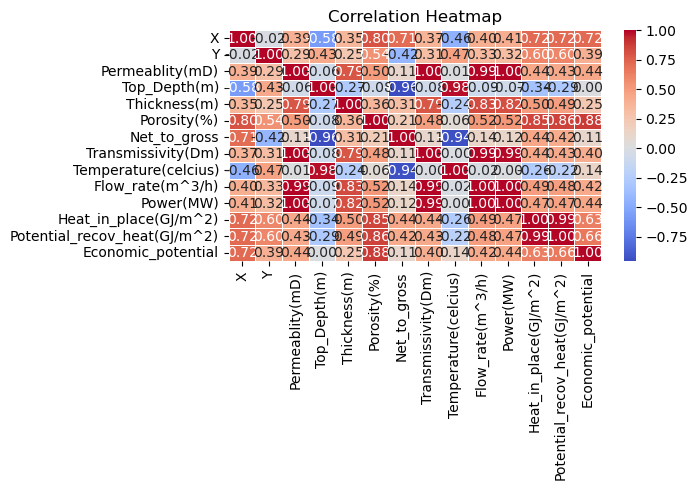

In [11]:
# Create correlation matrix
corr_matrix = numeric_df.corr()
# Plot heatmap
plt.figure(figsize=(6, 3))
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm', fmt='.2f',linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

#### Relationship Between features

In [12]:
thermogis_df.groupby(["Well_id","Scenerio","Flow_rate(m^3/h)"])["Permeablity(mD)"]\
    .sum()\
    .reset_index()\
    .sort_values(by="Permeablity(mD)", ascending=False)\
    .head(10)

,Well_id,Scenerio,Flow_rate(m^3/h),Permeablity(mD)
0,BLT_01,P10,469,521
15,ZST_01,P10,369,458
9,ODK_01,P10,362,410
1,BLT_01,P50,105,82
6,JUT_01,P10,110,81
16,ZST_01,P50,83,71
10,ODK_01,P50,76,63
7,JUT_01,P50,55,40
8,JUT_01,P90,26,20
2,BLT_01,P90,17,13


In [13]:
thermogis_df.groupby(["Well_id","Scenerio","Transmissivity(Dm)"])["Permeablity(mD)"]\
    .sum()\
    .reset_index()\
    .sort_values(by="Permeablity(mD)", ascending=False)\
    .head(10)

,Well_id,Scenerio,Transmissivity(Dm),Permeablity(mD)
0,BLT_01,P10,66.1,521
15,ZST_01,P10,48.8,458
9,ODK_01,P10,45.0,410
1,BLT_01,P50,9.3,82
6,JUT_01,P10,10.4,81
16,ZST_01,P50,6.8,71
10,ODK_01,P50,6.0,63
7,JUT_01,P50,4.8,40
8,JUT_01,P90,2.2,20
2,BLT_01,P90,1.3,13


In [14]:
thermogis_df.groupby(["Well_id","Scenerio","Transmissivity(Dm)"])["Power(MW)"]\
    .sum()\
    .reset_index()\
    .sort_values(by="Power(MW)", ascending=False)\
    .head(10)

,Well_id,Scenerio,Transmissivity(Dm),Power(MW)
0,BLT_01,P10,66.1,23.7
9,ODK_01,P10,45.0,19.7
15,ZST_01,P10,48.8,19.6
1,BLT_01,P50,9.3,5.1
6,JUT_01,P10,10.4,4.8
16,ZST_01,P50,6.8,4.2
10,ODK_01,P50,6.0,3.9
7,JUT_01,P50,4.8,2.3
8,JUT_01,P90,2.2,1.0
2,BLT_01,P90,1.3,0.6


## Data Visualization

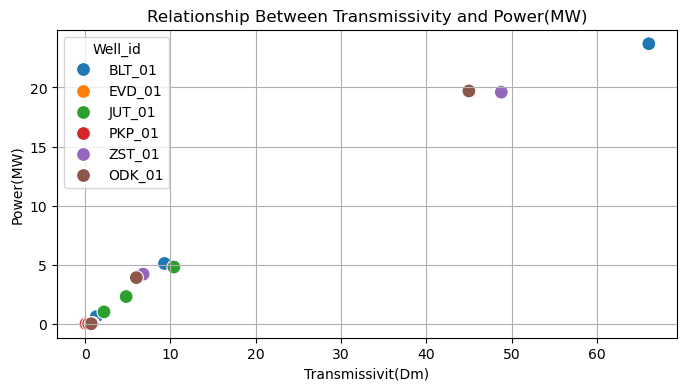

In [15]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=thermogis_df,x="Transmissivity(Dm)",y="Power(MW)", hue="Well_id",s=100)

plt.title("Relationship Between Transmissivity and Power(MW)")
plt.xlabel("Transmissivit(Dm)")
plt.ylabel("Power(MW)")

plt.grid(True)
plt.show()

#### Observation:
There is a lineaar relationship between Transmissivity and Power. 

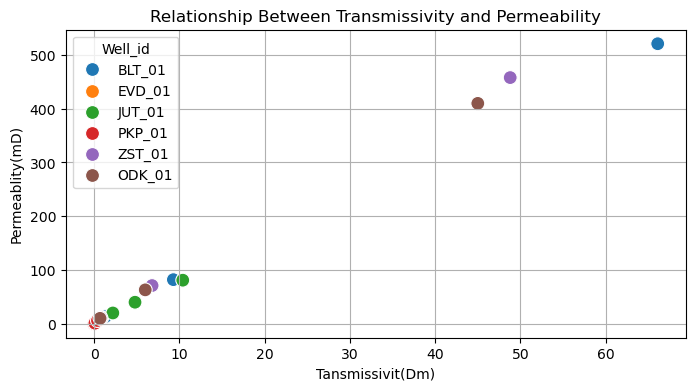

In [16]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=thermogis_df,x="Transmissivity(Dm)",y="Permeablity(mD)", hue="Well_id",s=100)

plt.title("Relationship Between Transmissivity and Permeability")
plt.xlabel("Tansmissivit(Dm)")
plt.ylabel("Permeablity(mD)")

plt.grid(True)
plt.show()

#### Temperature Analysis

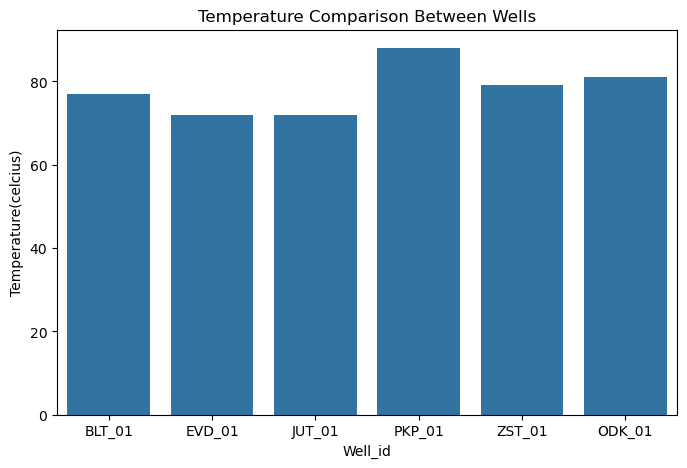

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(data=thermogis_df, x='Well_id',y='Temperature(celcius)')

plt.title('Temperature Comparison Between Wells')
plt.show()

#### Observation:
The PKP-01 well and ODK-01 well has the highest temperature

#### Flowrate Analysis

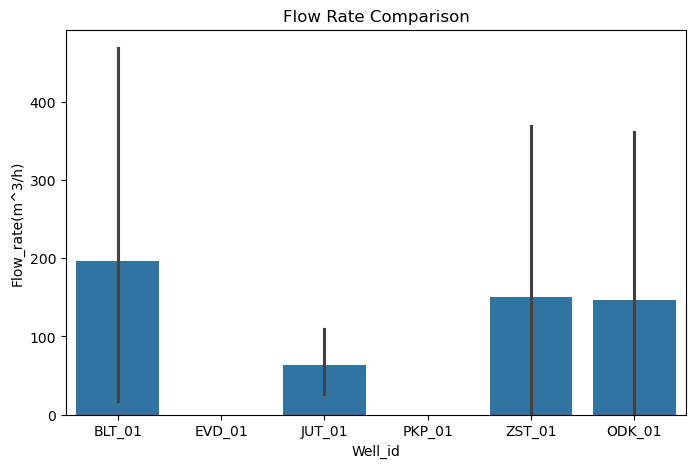

In [18]:
plt.figure(figsize=(8,5))
sns.barplot( data=thermogis_df,x='Well_id', y='Flow_rate(m^3/h)')

plt.title('Flow Rate Comparison')
plt.show()

#### Observation
- BLT-01,ZST-01, and ODK-01 flow rate are excellent 
- JUT-01 flow rate is moderate
- EVD-01 and PKP-01 flow rate is poor and is not productive

#### Permeability comparison

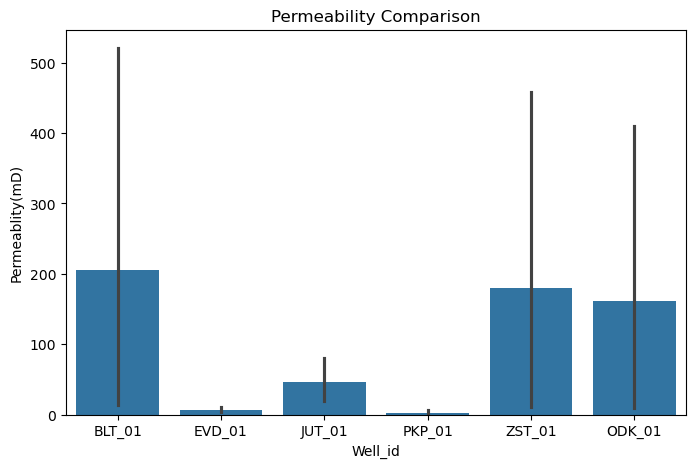

In [19]:
plt.figure(figsize=(8,5))
sns.barplot( data=thermogis_df,x='Well_id', y='Permeablity(mD)')

plt.title('Permeability Comparison')
plt.show()

#### Output Power Analysis

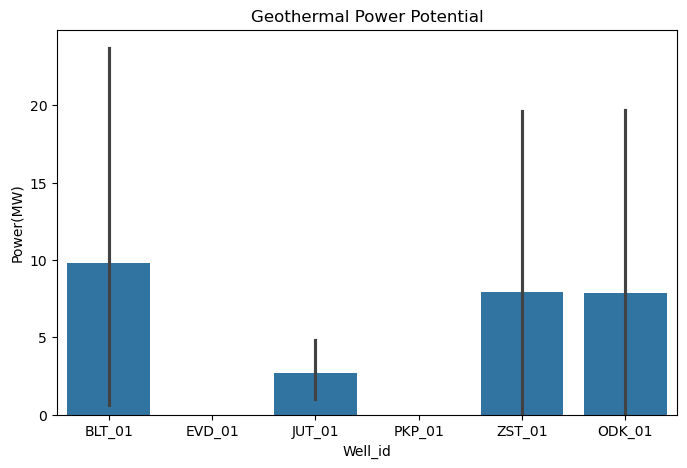

In [20]:
plt.figure(figsize=(8,5))
sns.barplot( data=thermogis_df, x='Well_id', y='Power(MW)')

plt.title('Geothermal Power Potential')
plt.show()

#### Temperture and flowrate scatterplot

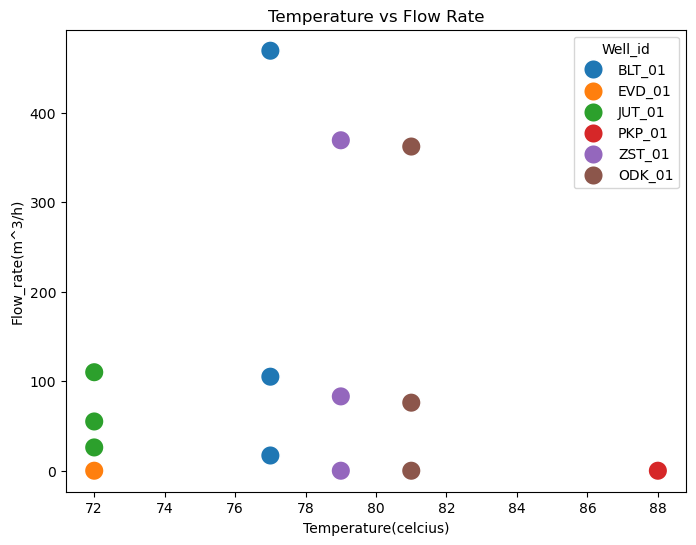

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=thermogis_df,x='Temperature(celcius)',y='Flow_rate(m^3/h)',hue='Well_id',s=200)
plt.title('Temperature vs Flow Rate')
plt.show()

#### Observation
The chart shows that flow rate is a critical factor alongside temperature. A high-temperature reservoir alone does not guarantee strong geothermal performance if fluid production is limited. Based on the combined temperature-flow relationship, BLT-01, ZST-01, and ODK-01 emerge as the most promising geothermal wells, while JUT-01 provides supplementary capacity. PKP-01 and EVD-01 are less attractive development targets due to their low flow rates.

#### Recoverable Heat Analysis

In [22]:
heat_df = thermogis_df.groupby("Well_id")["Potential_recov_heat(GJ/m^2)"]\
    .mean()\
    .reset_index()\
    .sort_values(by="Potential_recov_heat(GJ/m^2)", ascending=False)

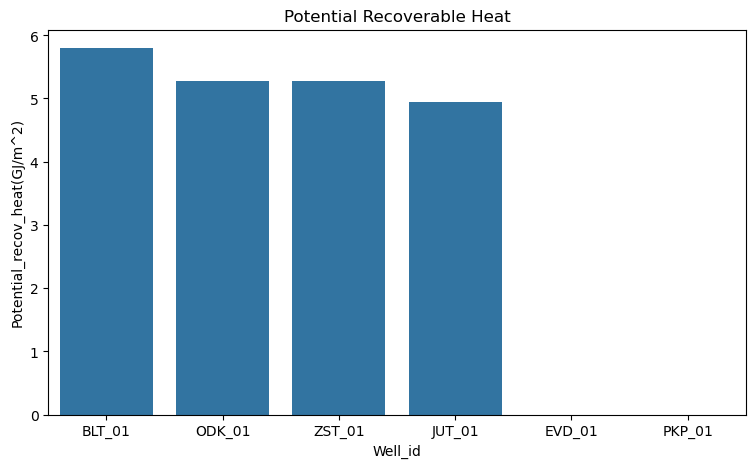

In [23]:
plt.figure(figsize=(9,5))
sns.barplot( data=heat_df,x="Well_id", y="Potential_recov_heat(GJ/m^2)")
plt.title("Potential Recoverable Heat")
plt.show()

### Economic potential analysis

In [24]:
thermogis_df.columns

Index(['Scenerio', 'Well_id', 'X', 'Y', 'Permeablity(mD)', 'Top_Depth(m)',
       'Thickness(m)', 'Porosity(%)', 'Net_to_gross', 'Transmissivity(Dm)',
       'Temperature(celcius)', 'Flow_rate(m^3/h)', 'Power(MW)',
       'Heat_in_place(GJ/m^2)', 'Potential_recov_heat(GJ/m^2)',
       'Economic_potential'],
      dtype='object')

In [25]:
economic_df = thermogis_df.groupby("Well_id")["Economic_potential"]\
    .mean()\
    .reset_index()\
    .sort_values(by="Economic_potential", ascending=False)

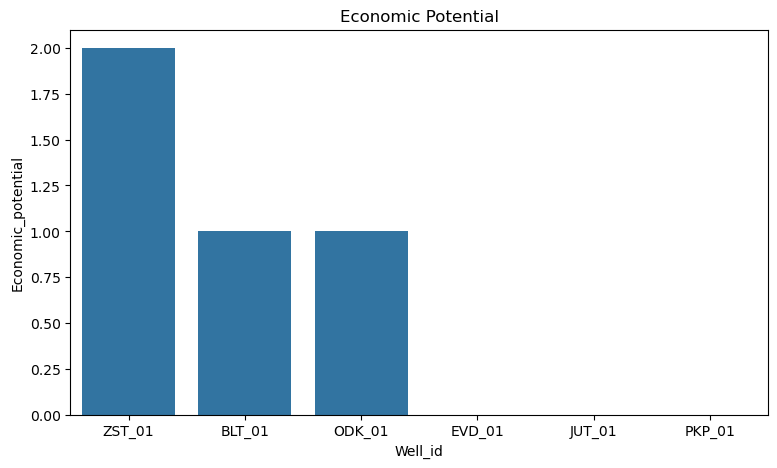

In [26]:
plt.figure(figsize=(9,5))
sns.barplot( data=economic_df,x="Well_id", y="Economic_potential")
plt.title("Economic Potential")
plt.show()

## Spatial Analysis

In [27]:
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx

In [28]:
#creat a geothermal geometry
geometry = gpd.points_from_xy( thermogis_df["X"],thermogis_df["Y"])

In [29]:
gdf = gpd.GeoDataFrame(thermogis_df, geometry=geometry)

In [30]:
gdf.head()

,Scenerio,Well_id,X,Y,Permeablity(mD),Top_Depth(m),Thickness(m),Porosity(%),Net_to_gross,Transmissivity(Dm),Temperature(celcius),Flow_rate(m^3/h),Power(MW),Heat_in_place(GJ/m^2),Potential_recov_heat(GJ/m^2),Economic_potential,geometry
0,P90,BLT_01,141577.55,456881.76,13,1837,67,17,0.98,1.3,77,17,0.6,24.8,5.8,1,POINT (141577.550 456881.760)
1,P50,BLT_01,141577.55,456881.76,82,1837,130,17,0.98,9.3,77,105,5.1,24.8,5.8,1,POINT (141577.550 456881.760)
2,P10,BLT_01,141577.55,456881.76,521,1837,194,17,0.98,66.1,77,469,23.7,24.8,5.8,1,POINT (141577.550 456881.760)
3,P90,EVD_01,136997.00,441189.00,3,1723,39,9,0.99,0.2,72,0,0.0,13.1,0.0,0,POINT (136997.000 441189.000)
4,P50,EVD_01,136997.00,441189.00,6,1723,76,9,0.99,0.4,72,0,0.0,13.1,0.0,0,POINT (136997.000 441189.000)


#### Well location

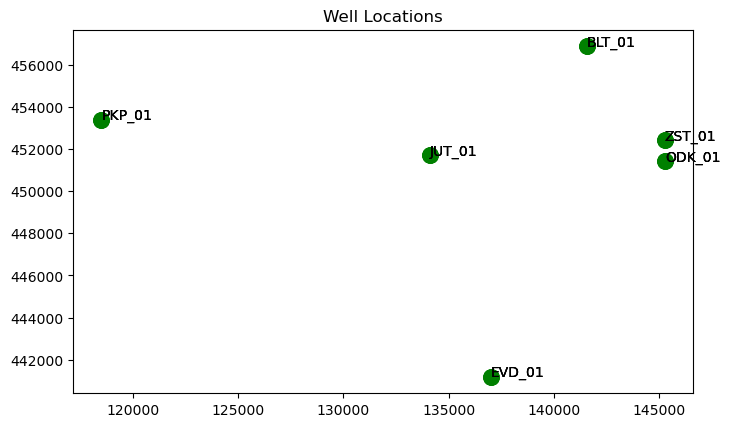

In [31]:
#Adding well location to the GIS Map
fig, ax = plt.subplots(figsize=(8,5))

gdf.plot( ax=ax,color='green', markersize=120)

for x, y, label in zip(
    gdf.geometry.x,
    gdf.geometry.y,
    gdf["Well_id"]
):
    ax.text(x, y, label)

plt.title("Well Locations")
plt.show()

#### Observation
1. BLT-01 stands out as the highest power well (23 MW), positioned at the highest northing (457,000) and eastern coordinates (141,000), making it the most productive and spatially distinct well in the dataset.
2. ZST_01 and ODK_01 cluster closely together in both location and power output (15–17 MW), suggesting they share similar reservoir conditions and likely draw from the same geothermal zone.
3. JUT_01 and PKP_01 record the lowest power outputs (near 0–2 MW), indicating weaker reservoir performance despite being spread across different spatial locations.
4. EVD_01 sits in isolation at the southern end (442,000 northing) with very low power output, suggesting it occupies a geologically distinct and less productive zone.

### Temperature Hotspot

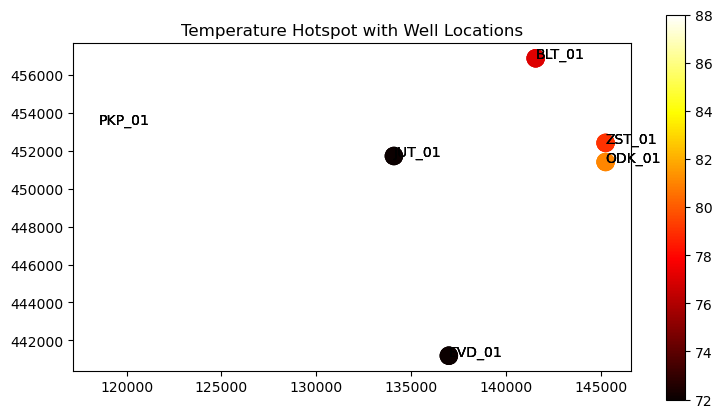

In [32]:
fig, ax = plt.subplots(figsize=(9,5))
# Plot temperature distribution
gdf.plot(column="Temperature(celcius)",cmap="hot",legend=True,markersize=150,ax=ax)
# Add well labels
for x, y, label in zip(
    gdf.geometry.x,
    gdf.geometry.y,
    gdf["Well_id"]
):
    ax.text( x,y, label, fontsize=10)
plt.title("Temperature Hotspot with Well Locations")
plt.show()

#### Observation
1. PKP-01 records the highest reservoir temperature (88°C), making it the hottest geothermal location in the field. However, temperature alone does not guarantee high geothermal productivity and should be evaluated alongside flow rate and recoverable heat.
2. ZST-01 and ODK-01 are located in close proximity and exhibit relatively high temperatures (~79–81°C). This clustering suggests the presence of a favorable geothermal zone that could support coordinated development and shared infrastructure.
3. BLT-01 shows a temperature of approximately 77°C and is located slightly northwest of the ZST–ODK cluster. When combined with its strong flow rate and recoverable heat characteristics, BLT-01 remains one of the most attractive development wells.
4. JUT-01 and EVD-01 have the lowest temperatures (~72°C), indicating lower thermal potential compared to the other wells. Nevertheless, JUT-01 may still contribute to district heating due to its favorable performance in other reservoir parameters.

#### Flow rate distribution map

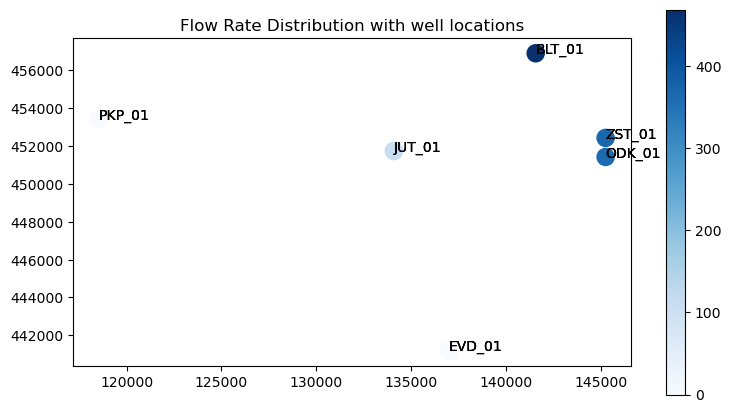

In [33]:
fig, ax = plt.subplots(figsize=(9,5))
gdf.plot(column="Flow_rate(m^3/h)",cmap="Blues",legend=True,markersize=150,ax=ax)
# Add well labels
for x, y, label in zip(
    gdf.geometry.x,
    gdf.geometry.y,
    gdf["Well_id"]
):
    ax.text( x,y, label, fontsize=10)
plt.title("Flow Rate Distribution with well locations")
plt.show()

### Power Hotspot

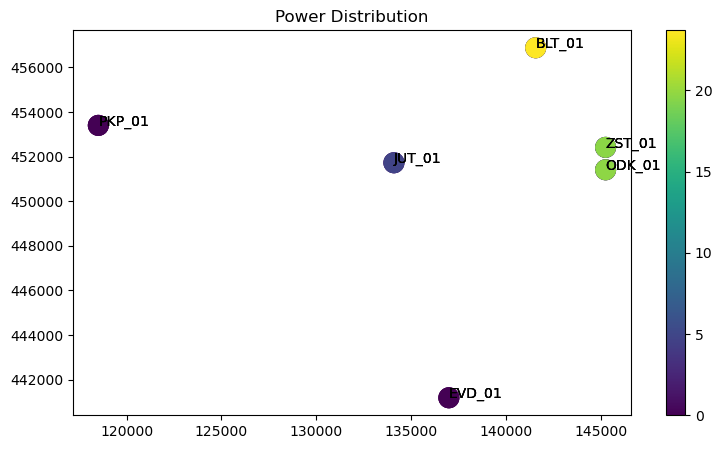

In [34]:
plt.figure(figsize=(9,5))

scatter = plt.scatter(gdf.geometry.x,gdf.geometry.y,c=gdf["Power(MW)"], s=200)
plt.colorbar(scatter)

for i,row in gdf.iterrows():
    plt.text(row["X"],row["Y"],row["Well_id"])

plt.title("Power Distribution")
plt.show()

#### Observation:
1. BLT_01 stands out as the highest power well (23 MW), positioned at the highest northing (457,000) and eastern coordinates (~141,000), making it the most productive and spatially distinct well in the dataset.
2. ZST_01 and ODK_01 cluster closely together in both location and power output (~15–17 MW), suggesting they share similar reservoir conditions and likely draw from the same geothermal zone.
3. JUT_01 and PKP_01 record the lowest power outputs (near 0–2 MW), indicating weaker reservoir performance despite being spread across different spatial locations.
4. EVD_01 sits in isolation at the southern end (~442,000 northing) with very low power output, suggesting it occupies a geologically distinct and less productive zone

## Scenerio -Based Analysis
#### What are P10, P50 and P90 Scenarios?
In geothermal resource assessment, reservoir performance is uncertain — we cannot know exactly how much energy a well will produce over its lifetime. To handle this uncertainty, engineers use **probability-based scenarios**:

| Scenario | Meaning | Interpretation |
|----------|---------|----------------|
| **P10** | 10% probability that output will be this high or higher | Optimistic / best case |
| **P50** | 50% probability : the most likely outcome | Base case / most realistic |
| **P90** | 90% probability that output will be at least this level | Conservative / worst case |


**Planning rule of thumb:** Projects are typically sized and financed around the **P50 scenario** because it represents the most balanced and realistic estimate of resource performance.
#### Why is the District Demand set at 15 MW?
The **15 MW** target represents the estimated heating and cooling load required to serve the district. This is the minimum capacity the geothermal system must deliver to be considered feasible for district energy supply
#### Why were PKP-01, EVD-01 and JUT-01 excluded?
For the Scenerio Analysis PKP, EVD and JUT wells were excluded because of their poor recoverable heat,poor economics and low productivity. So, the analysis is focused on the wells with better economics,higher recoverable heat and productivity that will meet the district heating and cooling demand of 15MW

In [36]:
gdf[['Well_id','Flow_rate(m^3/h)','Power(MW)','Economic_potential']]


,Well_id,Flow_rate(m^3/h),Power(MW),Economic_potential
0,BLT_01,17,0.6,1
1,BLT_01,105,5.1,1
2,BLT_01,469,23.7,1
3,EVD_01,0,0.0,0
4,EVD_01,0,0.0,0
5,EVD_01,0,0.0,0
6,JUT_01,26,1.0,0
7,JUT_01,55,2.3,0
8,JUT_01,110,4.8,0
9,PKP_01,0,0.0,0


Before focusing on the best wells, it is important to justify why three wells were dropped from the scenario analysis. The table below summarises their disqualifying characteristics compared to the selected wells:

| Well | Flow Rate | Power (MW) | Economic Potential | Decision |
|------|-----------|------------|-------------------|----------|
| BLT-01 | Excellent | ~23 MW | High | Selected |
| ZST-01 | Excellent | ~17 MW | High |  Selected |
| ODK-01 | Excellent | ~15 MW | High |  Selected |
| JUT-01 | Moderate | ~2 MW | Poor |  Excluded |
| PKP-01 | Poor | ~0 MW | Poor |  Excluded |
| EVD-01 | Poor | ~0 MW | Poor |  Excluded |

#### Create a Reservoir quality feature

In [35]:
gdf.columns

Index(['Scenerio', 'Well_id', 'X', 'Y', 'Permeablity(mD)', 'Top_Depth(m)',
       'Thickness(m)', 'Porosity(%)', 'Net_to_gross', 'Transmissivity(Dm)',
       'Temperature(celcius)', 'Flow_rate(m^3/h)', 'Power(MW)',
       'Heat_in_place(GJ/m^2)', 'Potential_recov_heat(GJ/m^2)',
       'Economic_potential', 'geometry'],
      dtype='object')

In [36]:
reservoir_cols = [ "Temperature(celcius)","Permeablity(mD)","Porosity(%)","Transmissivity(Dm)","Flow_rate(m^3/h)", "Potential_recov_heat(GJ/m^2)"]

In [37]:
best_wells = gdf[gdf["Well_id"].isin(["ZST_01","BLT_01","ODK_01"])].copy()

In [38]:
# Normalize the features because the parameters have different units.
reservoir_features = [ "Temperature(celcius)","Permeablity(mD)","Porosity(%)","Transmissivity(Dm)","Flow_rate(m^3/h)", "Potential_recov_heat(GJ/m^2)"]

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
best_wells[reservoir_features] = scaler.fit_transform(best_wells[reservoir_features])

In [39]:
# Create a reervoir quality index column
best_wells["Reservoir_quality"] = (
     best_wells["Temperature(celcius)"]*0.25 +
    
     best_wells["Flow_rate(m^3/h)"]*0.20 +

     best_wells["Permeablity(mD)"]*0.20 +

     best_wells["Porosity(%)"]*0.15 +

     best_wells["Transmissivity(Dm)"]*0.10 +

     best_wells["Potential_recov_heat(GJ/m^2)"]*0.10
)

**Note**: The values used in "Reservoir_quality" score are engineering-based weighting assumptions used to reflect the relative importance of each geothermal parameter for district heating feasibility.
The weights reflect the relative importance of each parameter to geothermal productivity — temperature and flow rate carry the highest influence (25% and 20% respectively) as they are the primary drivers of heat extraction capacity, while transmissivity and recoverable heat potential serve as secondary supporting indicators.

In [40]:
best_wells.head(2)

,Scenerio,Well_id,X,Y,Permeablity(mD),Top_Depth(m),Thickness(m),Porosity(%),Net_to_gross,Transmissivity(Dm),Temperature(celcius),Flow_rate(m^3/h),Power(MW),Heat_in_place(GJ/m^2),Potential_recov_heat(GJ/m^2),Economic_potential,geometry,Reservoir_quality
0,P90,BLT_01,141577.55,456881.76,0.005871,1837,67,0.0,0.98,0.009174,0.0,0.036247,0.6,24.8,1.0,1,POINT (141577.550 456881.760),0.109341
1,P50,BLT_01,141577.55,456881.76,0.140900,1837,130,0.0,0.98,0.131498,0.0,0.223881,5.1,24.8,1.0,1,POINT (141577.550 456881.760),0.186106


#### Reservoir Quality Assesment

In [41]:
best_wells.groupby("Well_id")["Reservoir_quality"].mean().sort_values(ascending=False)

Well_id
ODK_01    0.396640
BLT_01    0.298482
ZST_01    0.283462
Name: Reservoir_quality, dtype: float64

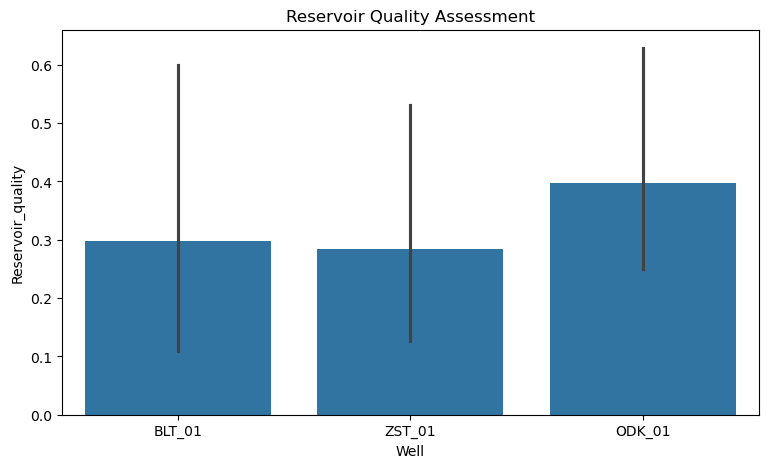

In [87]:
plt.figure(figsize=(9,5))
sns.barplot( data=best_wells, x="Well_id", y="Reservoir_quality")

plt.title("Reservoir Quality Assessment")
plt.xlabel("Well")
plt.show()

#### Observation :
ODK-01 well possesses the best reservoir quality, it records the highest mean reservoir quality score (0.40), making it the strongest performing well under this composite index. .

### Economic Risk Analysis

In [45]:
best_wells.groupby("Well_id")["Economic_potential"].mean().sort_values(ascending=False)

Well_id
ZST_01    2.0
BLT_01    1.0
ODK_01    1.0
Name: Economic_potential, dtype: float64

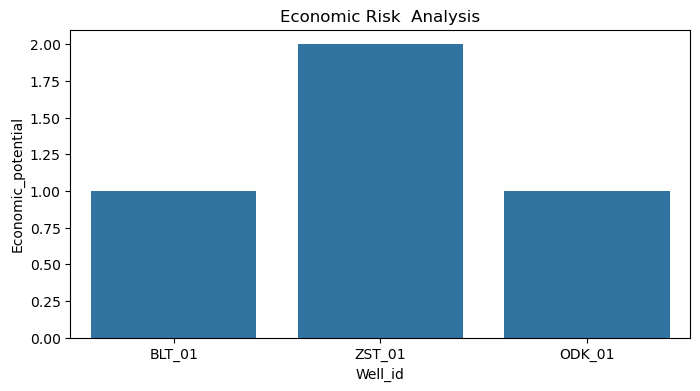

In [90]:
plt.figure(figsize=(8,4))
sns.barplot( data=best_wells, x="Well_id", y="Economic_potential")
plt.title("Economic Risk  Analysis")
plt.ylabel("Economic_potential")
plt.show()

#### Observation:
1. ZST-01, BLT-01, ODK-01 wells will yield a better Return on Investment (ROI) and better district heating feasibility.
2. JUT well has a very poor Economic potential, the well will be recommended as a secondary or future development target rather than a primary production well.

## District Heating Assessment

In [47]:
best_wells.columns

Index(['Scenerio', 'Well_id', 'X', 'Y', 'Permeablity(mD)', 'Top_Depth(m)',
       'Thickness(m)', 'Porosity(%)', 'Net_to_gross', 'Transmissivity(Dm)',
       'Temperature(celcius)', 'Flow_rate(m^3/h)', 'Power(MW)',
       'Heat_in_place(GJ/m^2)', 'Potential_recov_heat(GJ/m^2)',
       'Economic_potential', 'geometry', 'Reservoir_quality',
       'Recovery_Efficiency'],
      dtype='object')

In [63]:
district_demand_mw = 15  # Target city heating & cooling demand in MW
district_power_summary = (
     best_wells.groupby("Well_id")[["Power(MW)","Flow_rate(m^3/h)","Temperature(celcius)"]] 
    .mean()
    .reset_index()
    .sort_values('Power(MW)', ascending=False)
)

In [64]:
district_power_summary

,Well_id,Power(MW),Flow_rate(m^3/h),Temperature(celcius)
0,BLT_01,9.800000,0.420043,0.0
2,ZST_01,7.933333,0.321251,0.5
1,ODK_01,7.866667,0.311301,1.0


#### Total Geothermal capacity

In [65]:
total_geothermal_power_mw = district_power_summary['Power(MW)'].sum()
print(f'Total Geothermal Power Available from Selected Wells: {total_geothermal_power_mw:.2f} MW')

Total Geothermal Power Available from Selected Wells: 25.60 MW


## Scenerio - Based District Heating & Cooling Capacity
Now that we have identified the best performing wells (ZST-01, BLT-01, ODK-01), we evaluate whether their **combined power output** is sufficient to meet the 15 MW district heating and cooling demand across all three probability scenarios (P10, P50, P90).

This step answers the question: Under each scenario, does raw geothermal output alone meet the demand?
- If **Total Power ≥ 15 MW** --> demand is met without additional technology
- If **Total Power < 15 MW** --> a heat pump will be needed to amplify the output (covered in the next section)

#### KPI Before Heat Pump Integration 
The table below shows the **raw geothermal power** available from the selected wells under each scenario, compared directly against the 15 MW district demand.

In [66]:
scenario_power = (
     best_wells.groupby('Scenerio')['Power(MW)'].sum().reset_index()
    .rename(columns={'Power(MW)': 'Total_Power_MW'})
)

scenario_power['City_Demand_MW'] = district_demand_mw
scenario_power['Meets_Demand']   = scenario_power['Total_Power_MW'] >= district_demand_mw
scenario_power

,Scenerio,Total_Power_MW,City_Demand_MW,Meets_Demand
0,P10,63.0,15,True
1,P50,13.2,15,False
2,P90,0.6,15,False


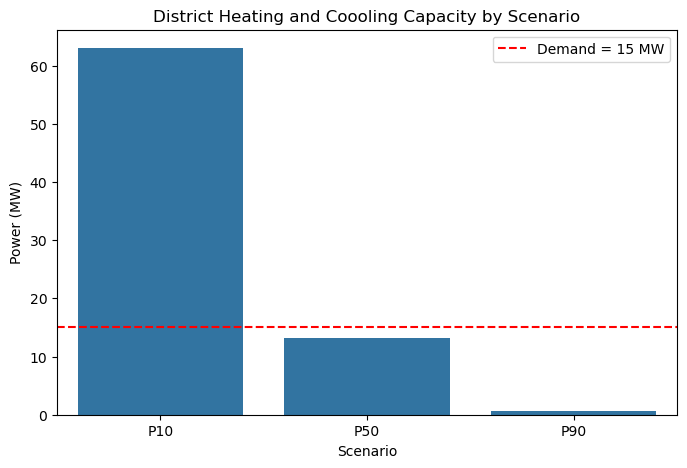

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(data=scenario_power,x='Scenerio', y='Total_Power_MW')
plt.axhline(
    district_demand_mw,
    color='red',
    linestyle='--',
    label=f'Demand = {district_demand_mw} MW'
)

plt.title('District Heating and Coooling Capacity by Scenario')
plt.ylabel('Power (MW)')
plt.xlabel('Scenario')
plt.legend()

plt.show()

#### Observation:
- The **P10 (optimistic) scenario** exceeded the 15 MW district demand from raw geothermal output alone , but it should not be used as the basis for infrastructure planning, as it has only a 10% probability of being achieved.
- The **P50 (most likely) scenario** falls below 15 MW on raw geothermal output, meaning the system needs a **heat pump** to bridge the gap and reliably meet demand.
- The **P90 (conservative) scenario** also falls short, highlighting that the project must include contingency planning for lower-than-expected reservoir performance.
#### Decision:
 We adopt the **P50 scenario** as the planning basis and integrate a heat pump to amplify the geothermal output to a level that comfortably meets and exceeds the 15 MW demand.

## Heat Pump Integeration
#### What is a Heat Pump and Why is it Needed?
A **geothermal heat pump** is a technology that uses the geothermal fluid extracted from the wells as an energy *source*, then transfers and amplifies that heat for use in buildings. 
The raw geothermal power from the P50 scenario is **not enough on its own** to meet the 15 MW district demand. The heat pump solves this by multiplying the available geothermal energy.
#### What is COP (Coefficient of Performance)?
The COP measures how efficient the heat pump is. A COP of 4 means:
- **For every 1 MW of geothermal energy input, the heat pump delivers 4 MW of useful thermal energy output**
#### The reason we used COP of 4
A COP of 4 iwas used because is a standard and conservative engineering assumption for geothermal district heating systems operating with reservoir temperatures in the 70–90°C range. Real-world geothermal heat pumps typically operate between COP 3 and 5, so COP = 4 represents a realistic mid-range estimate.

The formulas used are:
- HP Thermal Output (MW) = Geothermal Input (MW) × COP --> Total useful heat the heat pump delivers to the district
- Electrical Consumption (MW) = Geothermal Input (MW) × (COP − 1) --> Electricity needed to run the heat pump (the operating cost)
- Coverage (%) = HP Output / District Demand × 100 --> Percentage of the 15 MW district demand that is satisfied

In [68]:
COP = 4    # Coefficient of Performance
district_demand_mw  = 15   # District heating & cooling demand (MW)

In [69]:
heat_pump_df = scenario_power.copy()

# Geothermal power entering the heat pump
heat_pump_df["Geo_Input_MW"] = heat_pump_df["Total_Power_MW"]

# Useful heat delivered by the heat pump
heat_pump_df["HP_Output_MW"] = heat_pump_df["Geo_Input_MW"] * COP

# Electricity required by the heat pump
heat_pump_df["Electrical_Input_MW"] = heat_pump_df["Geo_Input_MW"] * (COP - 1)

# Percentage of district demand covered
heat_pump_df["Coverage_%"] = (heat_pump_df["HP_Output_MW"] / district_demand_mw) * 100

# Excess heat after meeting demand
heat_pump_df["Surplus_MW"] = heat_pump_df["HP_Output_MW"] - district_demand_mw

# Whether demand is met
heat_pump_df["Meets_Demand"] = heat_pump_df["HP_Output_MW"] >= district_demand_mw

# Round values for presentation
heat_pump_df = heat_pump_df.round({
    "Geo_Input_MW": 2,
    "HP_Output_MW": 2,
    "Electrical_Input_MW": 2,
    "Coverage_%": 1,
    "Surplus_MW": 2
})

heat_pump_df

,Scenerio,Total_Power_MW,City_Demand_MW,Meets_Demand,Geo_Input_MW,HP_Output_MW,Electrical_Input_MW,Coverage_%,Surplus_MW
0,P10,63.0,15,True,63.0,252.0,189.0,1680.0,237.0
1,P50,13.2,15,True,13.2,52.8,39.6,352.0,37.8
2,P90,0.6,15,False,0.6,2.4,1.8,16.0,-12.6


#### Well-Level Heat Pump Contribution

In [70]:
well_hp = district_power_summary.copy()
well_hp['HP_Thermal_Output_MW'] = (well_hp['Power(MW)'] * COP).round(2)
well_hp['Electrical_Input_MW']  = (well_hp['Power(MW)'] * (COP - 1)).round(2)
well_hp['Contribution_%']       = (well_hp['HP_Thermal_Output_MW'] / district_demand_mw * 100).round(1)

well_hp[['Well_id', 'Power(MW)', 'HP_Thermal_Output_MW', 'Electrical_Input_MW', 'Contribution_%']]

,Well_id,Power(MW),HP_Thermal_Output_MW,Electrical_Input_MW,Contribution_%
0,BLT_01,9.800000,39.20,29.4,261.3
2,ZST_01,7.933333,31.73,23.8,211.5
1,ODK_01,7.866667,31.47,23.6,209.8


### Heat Pump Impact By Scenerio

In [153]:
heat_pump_df.columns

Index(['Scenerio', 'Total_Power_MW', 'City_Demand_MW', 'Meets_Demand',
       'Geo_Input_MW', 'HP_Output_MW', 'Electrical_Input_MW', 'Coverage_%',
       'Surplus_MW'],
      dtype='object')

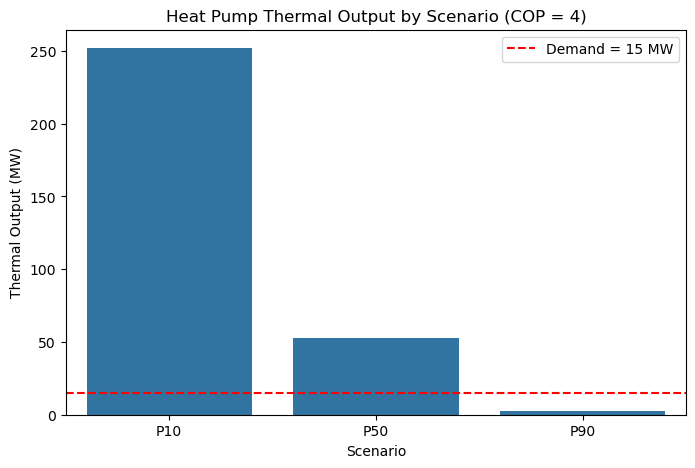

In [72]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=heat_pump_df,
    x="Scenerio",
    y="HP_Output_MW"
)

plt.axhline(
    district_demand_mw,
    color="red",
    linestyle="--",
    label=f"Demand = {district_demand_mw} MW"
)

plt.title("Heat Pump Thermal Output by Scenario (COP = 4)")
plt.ylabel("Thermal Output (MW)")
plt.xlabel("Scenario")
plt.legend()

plt.show()

#### Observation:
The heat pump integration analysis demonstrates that the geothermal resource has strong potential to support a district heating and cooling network. Under the most likely development scenario (P50), the geothermal system delivers approximately 53 MW of useful thermal energy, exceeding the estimated district demand of 15 MW

## Well contribution to District Heatiing and Cooling

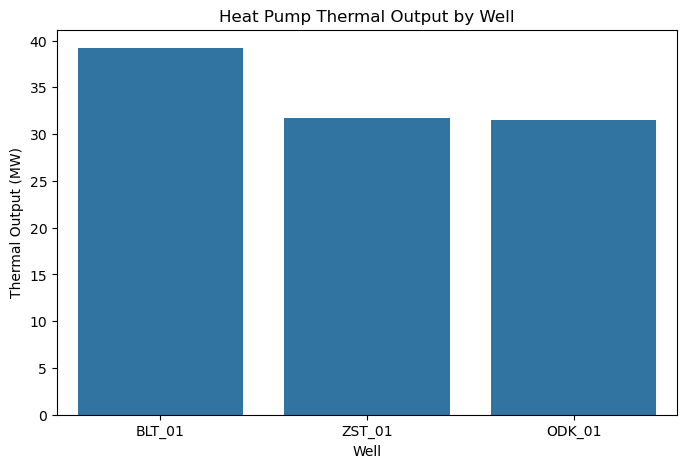

In [73]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=well_hp,
    x="Well_id",
    y="HP_Thermal_Output_MW"
)

plt.title("Heat Pump Thermal Output by Well")
plt.ylabel("Thermal Output (MW)")
plt.xlabel("Well")

plt.show()

In [74]:
heat_pump_df.head()

,Scenerio,Total_Power_MW,City_Demand_MW,Meets_Demand,Geo_Input_MW,HP_Output_MW,Electrical_Input_MW,Coverage_%,Surplus_MW
0,P10,63.0,15,True,63.0,252.0,189.0,1680.0,237.0
1,P50,13.2,15,True,13.2,52.8,39.6,352.0,37.8
2,P90,0.6,15,False,0.6,2.4,1.8,16.0,-12.6


### K.P.I After HeatPump Integration

In [77]:
heat_pump_df[[
    "Scenerio",
    "City_Demand_MW",
    "HP_Output_MW",
    "Coverage_%",
    "Meets_Demand"
]]

,Scenerio,City_Demand_MW,HP_Output_MW,Coverage_%,Meets_Demand
0,P10,15,252.0,1680.0,True
1,P50,15,52.8,352.0,True
2,P90,15,2.4,16.0,False


## Final Conclusion
**The assessment of the geothermal resource indicates that the study area possesses significant potential for supporting a district heating and cooling network, particularly when geothermal production is integrated with heat pump technology (COP = 4)**.

**Under the most likely scenario (P50)**, the geothermal system delivers approximately **52.8 MW** of useful thermal energy, covering 352% of the district heating demand of 15 MW. This result confirms that the geothermal resource can comfortably satisfy the projected heating and cooling requirements while providing substantial excess capacity for future expansion of the district energy network

**Under the optimistic scenario (P10)**, the system generates approximately 252 MW of useful thermal energy, equivalent to 1,680% of the required demand. This indicates a very large geothermal resource base and highlights the potential for scaling the system beyond the current district heating and cooling requirements. Such capacity could support additional residential developments, commercial facilities, public institutions, and industrial users

**Under the conservative scenario (P90)**, the available thermal output is approximately 2.4 MW, covering only 16% of the required demand. This suggests that the project is sensitive to reservoir uncertainty and that geothermal energy alone may not be sufficient during worst-case operating conditions. Consequently, system planning should incorporate contingency measures such as auxiliary heating systems, phased field development, or additional production wells to enhance reliability**

## Recommendation
Based on the technical, economic, and scenario analyses:
1. ZST-01, BLT-01 and ODK-01 should be prioritized as the primary production wells due to their strong geothermal performance and favorable development characteristics.
2. JUT-01 should be retained as a strategic reserve or future expansion well, given its strong technical performance despite lower economic attractiveness.
3. Project sizing and financial evaluation should be based primarily on the P50 scenario